In [1]:
import matplotlib.pyplot as plt
import numpy as np

from bandit import Bandit
from bandit_methods import bandit_av_method_run

%load_ext autoreload
%autoreload 2

## Initialize a specific 10-armed bandit

In [2]:
bandit = Bandit(10)

In [3]:
bandit._q_true

array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
       -1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393])

In [4]:
[bandit.sample(a).item() for a in range(0,10)]

[1.1841150546172599,
 -0.2621921708115472,
 0.8164818933676733,
 2.0678059233592467,
 -1.4835258464017909,
 -2.1614719697455564,
 0.49659118724978424,
 -1.275125193172581,
 0.8616491438029837,
 -0.9029698385598329]

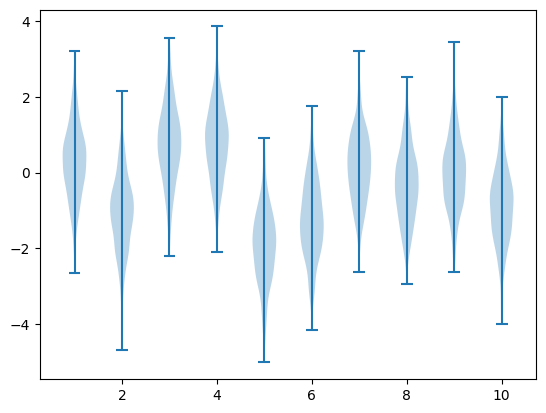

In [5]:
rewards = [bandit.sample(a, 500) for a in range(0,10)]

plt.violinplot(rewards);

## $\epsilon$-greedy action-value method

In [7]:
def simulate(R, epsilon, T, k, **kwargs):
    # def simulate(R, epsilon, T, k, q_true_mean = 0, q_true_var = 1, drift_var = 0.0, step_size: Callable[[int], float] = lambda x: 1/x):
    """
    Run R runs of the epsilon-greedy algorithm on R different k-armed bandits for T time steps, and average the rewards from all runs for each time step.

    Args:
        R: number of runs
        epsilon: probability with which an exploratory action is taken
        T: number of timesteps played
        k: number of arms in the bandit
        q_true_mean: mean of the q_true values for each of the k arms
        q_true_var: variance of the q_true values each of the k arms
        drift_var: if the bandit is non stationary, the q_true values take a random walk with variance drift_var and mean 0 at every step
    """

    # Get optional bandit and algorithm args from kwargs
    bandit_args = {k:kwargs[k] for k in kwargs.keys() & ["q_true_mean", "q_true_var", "drift_var"]}
    algo_args = {k:kwargs[k] for k in kwargs.keys() & ["step_size"]}

    average_rewards = np.zeros(T)
    number_optimal_actions = np.zeros(T)
    
    for r in range(0,R):
        bandit = Bandit(k, **bandit_args)
        bandit_best_action = bandit._best_action
        
        rewards, actions = bandit_av_method_run(bandit.reward, k, T, epsilon, **algo_args)
        
        average_rewards = average_rewards + 1/(r+1)*(rewards - average_rewards)
        number_optimal_actions += (actions == bandit_best_action)

    percent_optimal_actions = number_optimal_actions*100/R

    return average_rewards, percent_optimal_actions

In [8]:
%%time

# Run 3000 runs for three different values of epsilon

k = 10                         # number of arms in the bandit
T = 3000                       # number of timesteps played
epsilons = [0.0, 0.01, 0.1]
R = 2000                       # number of runs to play in the simulation

average_rewards = np.empty((len(epsilons), T))
percent_optimal_actions = np.empty((len(epsilons), T))

for i, epsilon in enumerate(epsilons):
    average_rewards[i], percent_optimal_actions[i] = simulate(R, epsilon, T, k)

print("Average reward: ", np.mean(average_rewards, axis=1))

Average reward:  [1.06291243 1.36468781 1.3664874 ]
CPU times: user 9min 46s, sys: 94.4 ms, total: 9min 46s
Wall time: 9min 46s


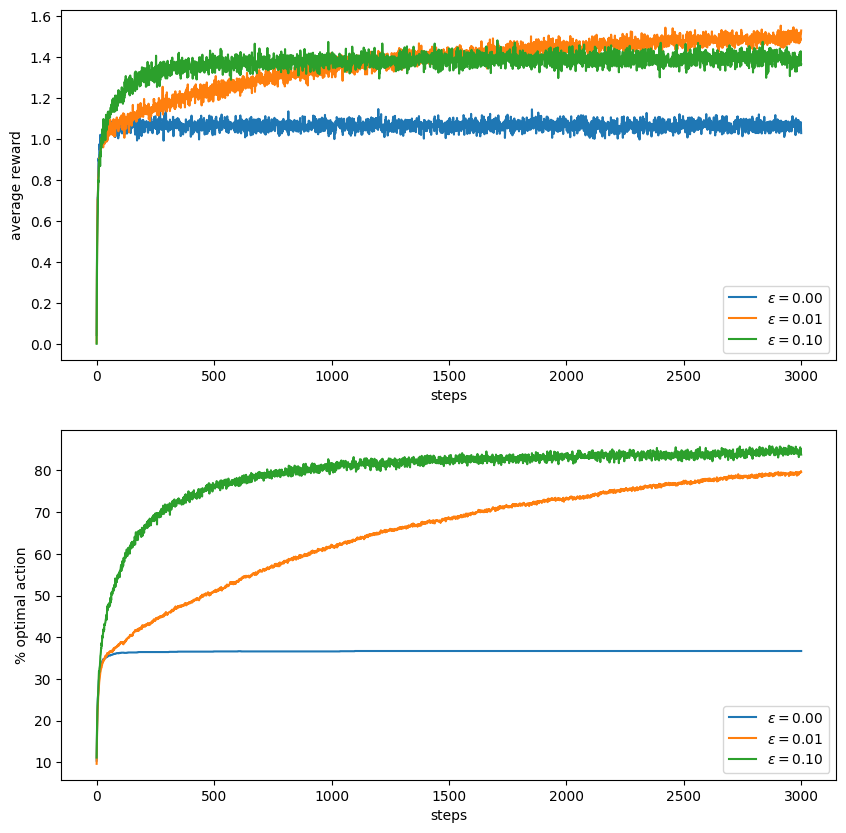

In [9]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, epsilon in enumerate(epsilons):
    plt.plot(percent_optimal_actions[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()

plt.savefig('../images/figure_2_2.png')

## Non-stationary 10-armed bandit

In [10]:
bandit = Bandit(10, q_true_mean = 0.8, q_true_var = 0, drift_var = 0.01)

In [11]:
bandit._q_true

array([0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8])

In [12]:
[bandit.sample(a).item() for a in range(0,10)]

[-0.25836712496695635,
 0.9777027023775389,
 1.2121876855052627,
 -0.04186356663051649,
 2.246354445157943,
 1.8454301202863321,
 1.402863298205109,
 0.4939225562197935,
 -0.03257417829599907,
 0.08835037191658324]

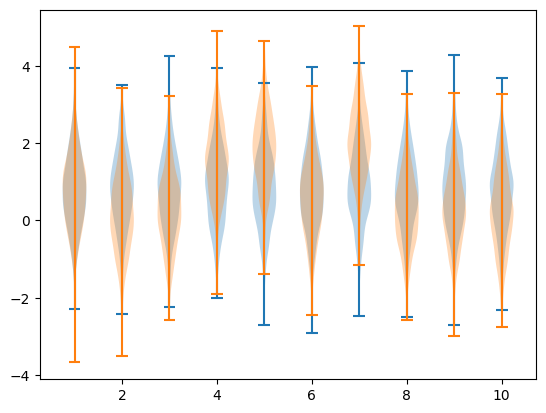

In [13]:
rewards_start = [bandit.sample(a, 1000) for a in range(0,10)]

# Take a number of time steps, at each of which the q_true vlus take independent random walks
for i in range(10000):
    bandit.reward(0)
rewards_end = [bandit.sample(a, 1000) for a in range(0,10)]

plt.violinplot(rewards_start);
plt.violinplot(rewards_end);

In [14]:
bandit._q_true

array([0.85653814, 0.10938826, 0.20688314, 1.53155156, 1.8800295 ,
       0.56337775, 1.98171771, 0.22746463, 0.26414291, 0.13214166])

# Simulate non-stationary Bandit algo

### Using same sample-average action-value method as before

In [15]:
%%time

# Run 3000 runs for three different values of epsilon

k = 10                         # number of arms in the bandit
T = 10000                      # number of timesteps played
epsilons = [0.1]
R = 2000                       # number of runs to play in the simulation

average_rewards = np.empty((len(epsilons), T))
percent_optimal_actions = np.empty((len(epsilons), T))

for i, epsilon in enumerate(epsilons):
    average_rewards[i], percent_optimal_actions[i] = simulate(R, epsilon, T, k, q_true_mean = 0.5, q_true_var = 0, drift_var = 0.01)

print("Average reward: ", np.mean(average_rewards, axis=1))

Average reward:  [1.20007579]
CPU times: user 10min 57s, sys: 155 ms, total: 10min 57s
Wall time: 10min 57s


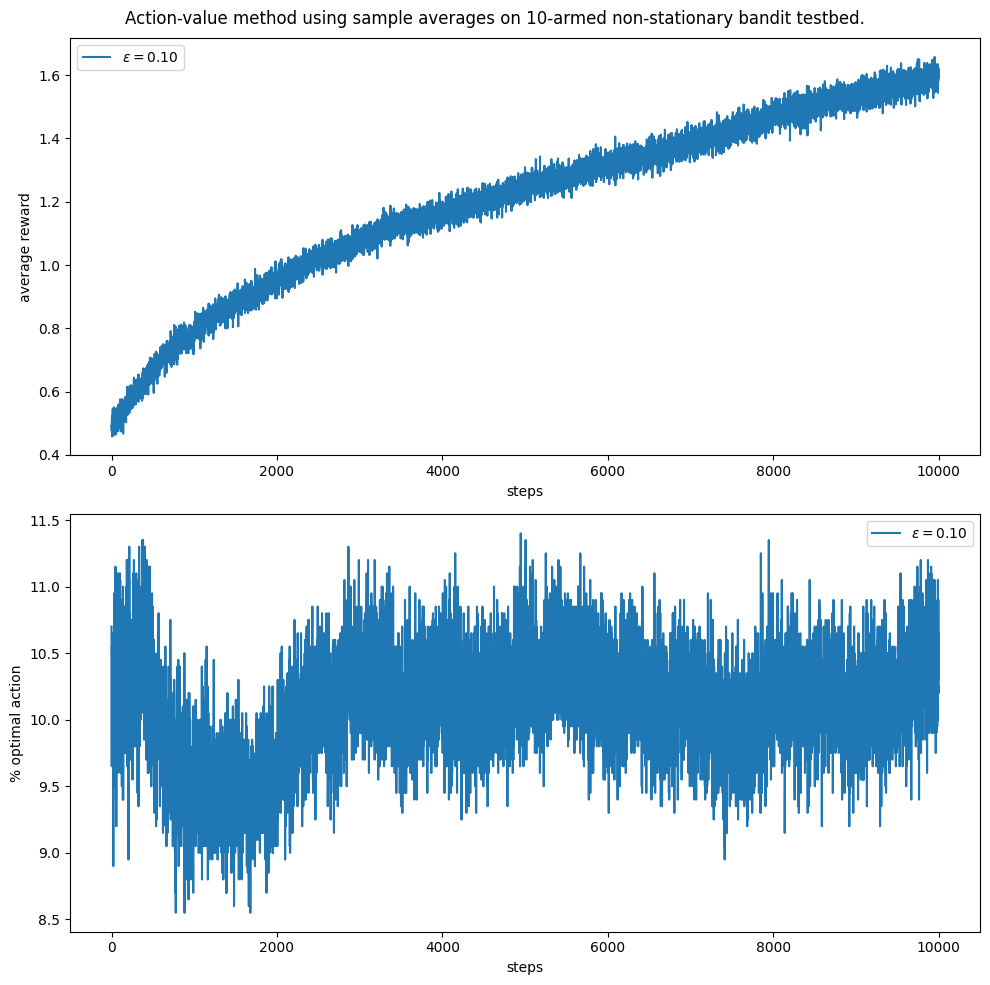

In [16]:
plt.figure(figsize=(10, 10))
plt.suptitle(f"Action-value method using sample averages on {k}-armed non-stationary bandit testbed.")

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, epsilon in enumerate(epsilons):
    plt.plot(percent_optimal_actions[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()

plt.tight_layout()

plt.savefig('../images/figure_2_2_ns.png')

### Using constant step-size action-value method

In [17]:
%%time

# Run 3000 runs for three different values of epsilon

k = 10                         # number of arms in the bandit
T = 10000                      # number of timesteps played
epsilons = [0.1]
R = 2000                       # number of runs to play in the simulation

average_rewards = np.empty((len(epsilons), T))
percent_optimal_actions = np.empty((len(epsilons), T))

for i, epsilon in enumerate(epsilons):
    average_rewards[i], percent_optimal_actions[i] = simulate(R, epsilon, T, k, q_true_mean = 0.5, q_true_var = 0, drift_var = 0.01, step_size=lambda x:0.1)

print("Average reward: ", np.mean(average_rewards, axis=1))

Average reward:  [1.36344153]
CPU times: user 10min 56s, sys: 112 ms, total: 10min 56s
Wall time: 10min 56s


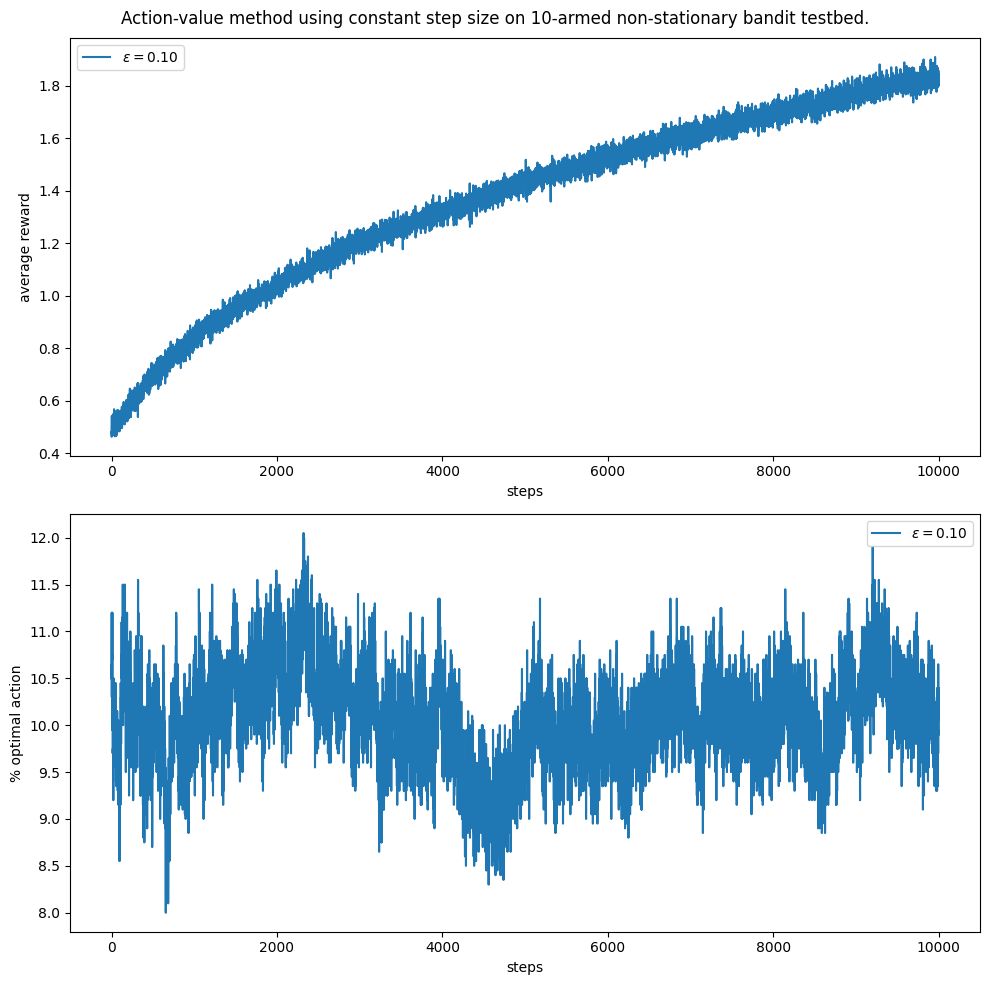

In [18]:
plt.figure(figsize=(10, 10))
plt.suptitle(f"Action-value method using constant step size on {k}-armed non-stationary bandit testbed.")

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

plt.subplot(2, 1, 2)
for i, epsilon in enumerate(epsilons):
    plt.plot(percent_optimal_actions[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('% optimal action')
plt.legend()

plt.tight_layout()

plt.savefig('../images/figure_2_2_ns_cs.png')